### CREDIT CARD FRAUD DETECTION

Load all necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import xgboost as xgb
import shap
import joblib

Import & Inspect Dataset

In [2]:
df = pd.read_csv("creditcard.csv")
print(df.head(5))
print(df.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

Check proportion of both occurence

In [3]:
fraud_rate = df["Class"].value_counts(normalize=True)*100
print(fraud_rate)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


Plot distribution of both occurrence

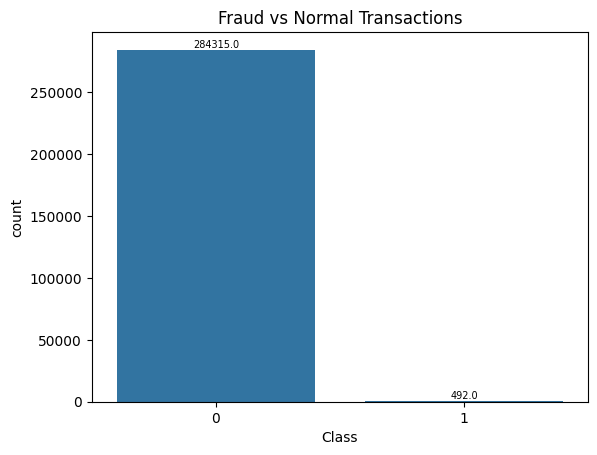

In [4]:
ax = sns.countplot(x="Class", data=df)
plt.title("Fraud vs Normal Transactions")
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=7)
plt.show()

Check for outliers with Boxplot

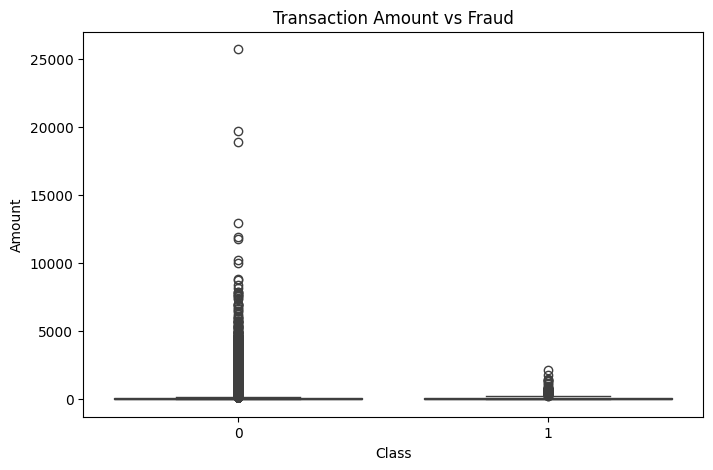

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

Create 'Hour' column with 'Time' column

In [6]:
df["Hour"] = (df["Time"]//3600) % 24
df.tail(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,23.0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,23.0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,23.0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,23.0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0,23.0


Check the hourly distribution of classes

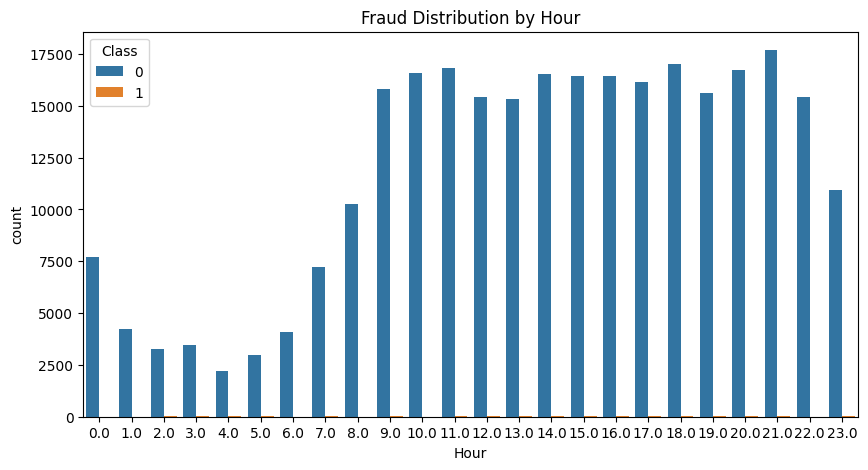

In [7]:
plt.figure(figsize=(10,5))
sns.countplot(x="Hour", hue="Class", data=df)
plt.title("Fraud Distribution by Hour")
plt.show()

Split Dataset into Features & Target

In [8]:
feature_names = ['Time'] + [f'V{i}' for i in range(1,29)] + ['Amount']
feature_names_with_hour = feature_names + ['Hour']

x = df[feature_names]
y = df["Class"]

Split Dataset into Training & Testing sets

In [9]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

print(x_test.shape,x_train.shape)

(56962, 30) (227845, 30)


Balance Imblanced Dataset

In [10]:
smote = SMOTE(sampling_strategy=0.2, random_state=42)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

print(f"Before SMOTE: {sum(y_train==1)} fraud cases")
print(f"After SMOTE: {sum(y_train_res==1)} fraud cases")

Before SMOTE: 394 fraud cases
After SMOTE: 45490 fraud cases


Feature Scaling

In [11]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_res)
x_test_scaled = scaler.transform(x_test)

Note: we do NOT “fit” on the test set, because we don’t want to leak information from the test set into training.

Train Logistic Regression Model

In [12]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(x_train_scaled, y_train_res)

y_pred_proba_lr = lr.predict_proba(x_test_scaled)[:,1]
ap_lr = average_precision_score(y_test, y_pred_proba_lr)
print(f"Logistic Regression AUPRC: {ap_lr:.4f}")

Logistic Regression AUPRC: 0.7365


Train Random Forest Classifier Model

In [13]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(x_train_res, y_train_res)

y_pred_proba_rf = rf.predict_proba(x_test)[:,1]
ap_rf = average_precision_score(y_test, y_pred_proba_rf)
print(f"Random Forest AUPRC: {ap_rf:.4f}")

Random Forest AUPRC: 0.8263


Train XGBoost Model

In [14]:
scale_pos_weight = (y_train==0).sum() / (y_train==1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(x_train, y_train)

y_pred_proba_xgb = xgb_model.predict_proba(x_test)[:,1]
ap_xgb = average_precision_score(y_test, y_pred_proba_xgb)

print(f"XGBoost AUPRC: {ap_xgb:.4f}")

XGBoost AUPRC: 0.8861


Model Performance Summary

In [15]:
results = {
    "Logistic Regression": ap_lr,
    "Random Forest": ap_rf,
    "XGBoost": ap_xgb
}

print("\nModel Performance Summary (AUPRC)")
for model, score in results.items():
    print(f"{model}: {score:.4f}")

best_model = max(results, key=results.get)
best_score = results[best_model]

print("\nBest Model Based on AUPRC:")
print(f"{best_model} with a score of {best_score:.4f}")


Model Performance Summary (AUPRC)
Logistic Regression: 0.7365
Random Forest: 0.8263
XGBoost: 0.8861

Best Model Based on AUPRC:
XGBoost with a score of 0.8861


Model Threshold Optimization (XGBoost)

In [30]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_xgb)
target_recall = 0.80

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)

best_idx = np.argmax(f1_scores[:-1])

optimal_threshold = thresholds[best_idx]

print("Optimal threshold:", optimal_threshold)

Optimal threshold: 0.9869816


Final Model Evaluation (Using Selected Threshold)

In [17]:
y_pred_xgb = (y_pred_proba_xgb >= optimal_threshold).astype(int)

In [33]:
precision = precision_score(y_test, y_pred_xgb)
print("Precision:", precision)

Precision: 0.975609756097561


In [32]:
recall = recall_score(y_test, y_pred_xgb)
print("Recall:", recall)

Recall: 0.8163265306122449


In [31]:
f1 = f1_score(y_test, y_pred_xgb)
print("F1 Score:", f1)

F1 Score: 0.8888888888888888


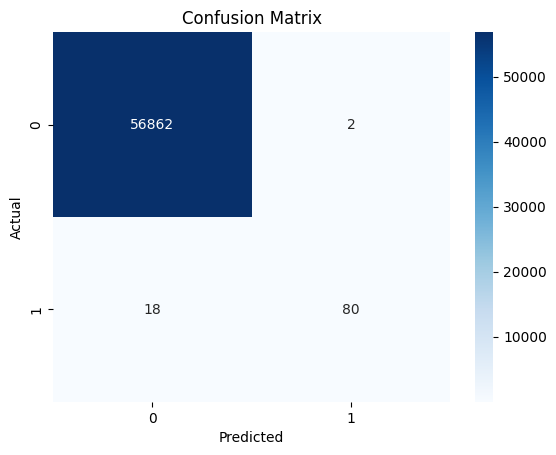

In [21]:
cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.98      0.82      0.89        98

    accuracy                           1.00     56962
   macro avg       0.99      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



Compute SHAP values 

In [23]:
sample_input = x_test.head(100)
explainer = shap.Explainer(xgb_model)
shap_values = explainer(sample_input)

SHAP Summary Plot (Global Feature Importance)

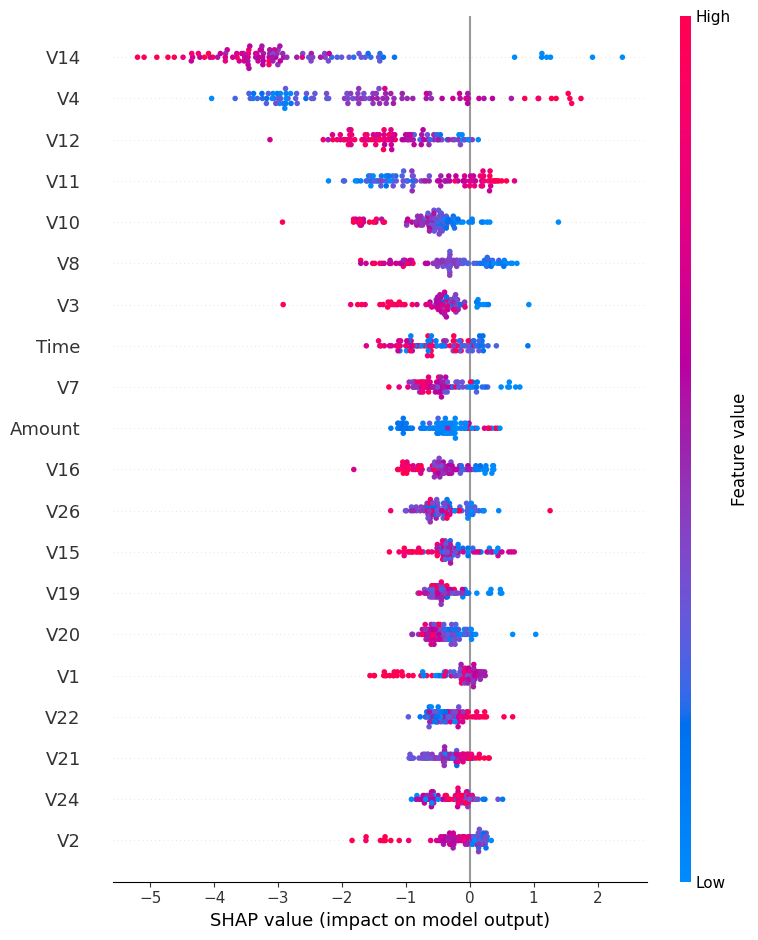

In [24]:
shap.summary_plot(shap_values.values, sample_input, show=True)

SHAP Feature Importance (Bar Plot)

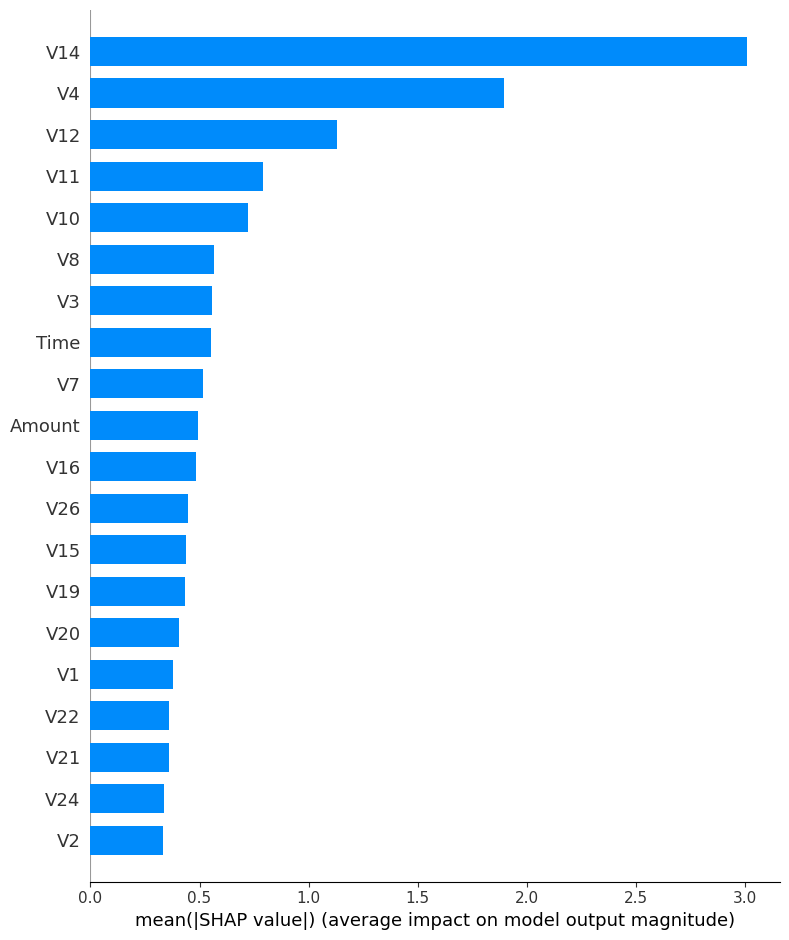

In [25]:
shap.summary_plot(shap_values, x_test, plot_type="bar")

SHAP Dependence Plot (Feature Impact Analysis)

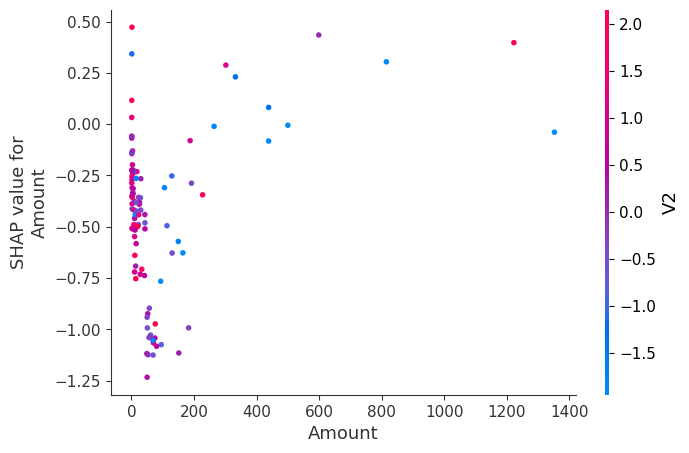

In [26]:
shap.dependence_plot("Amount", shap_values.values, sample_input, show=True)

Conclusion 

In [27]:
print("\nConclusion:")
print(
    f"Among the evaluated models, {best_model} achieved the highest AUPRC score "
    f"of {best_score:.4f}. AUPRC is appropriate for this imbalanced classification problem. "
    "Therefore, this model is selected for deployment."
)


Conclusion:
Among the evaluated models, XGBoost achieved the highest AUPRC score of 0.8861. AUPRC is appropriate for this imbalanced classification problem. Therefore, this model is selected for deployment.


Save all deployment objects (models, scaler & SHAP explainer)

In [29]:
xgb_model.save_model("xgb_model.json")
print("xgb_model.json saved successfully")

deployment_objects = {
    "logreg": lr,
    "rf": rf,
    "scaler": scaler,
    "feature_names": feature_names,
    "threshold_xgb": optimal_threshold
}

joblib.dump(deployment_objects, "fraud_detection_deployment_objects.pkl")
print("deployment objects saved successfully")

xgb_model.json saved successfully
deployment objects saved successfully
